In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('../../data/fin_reduced2.csv')

In [31]:
df.columns

Index(['num parti', 'nom parti', 'année', 'immobilisations incorporelles',
       'écarts d'acquisition', 'terrains et constructions',
       'autres immobilisations corporelles',
       'participations et créances rattachées',
       'prêts à des partis ou groupements politiques',
       'autres immobilisations financières', 'stocks et en-cours',
       'créances clients et comptes rattachés', 'autres créances',
       'valeurs mobilières de placement', 'disponibilités',
       'charges constatées d'avance', 'total général (i + ii + iii)',
       'réserves', 'excédent ou déficit de l'exercice',
       'provisions pour risques', 'provisions pour charges',
       'emprunts et dettes auprès d'établissement de crédit',
       'dettes fournisseurs et comptes rattachés',
       'dettes fiscales et sociales', 'autres dettes',
       'produits constatés d'avance', 'total général (i + ii + iii + iv)',
       'communication (presse, publications, télévisions, publicité, sites internet, réseaux 

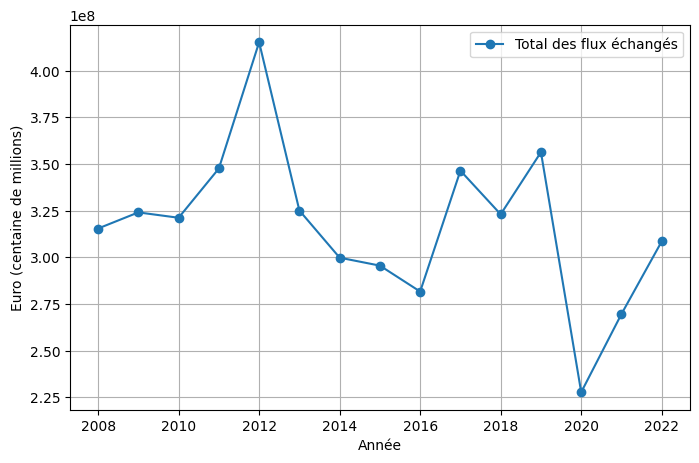

In [16]:
flux=df.groupby('année')["total flux"].sum()
plt.figure(figsize=(8, 5))
plt.plot(flux.index, flux.values, marker="o", linestyle="-", label="Total des flux échangés")
plt.xlabel("Année")
plt.ylabel("Euro (centaine de millions)")

plt.legend()
plt.grid()
plt.show()

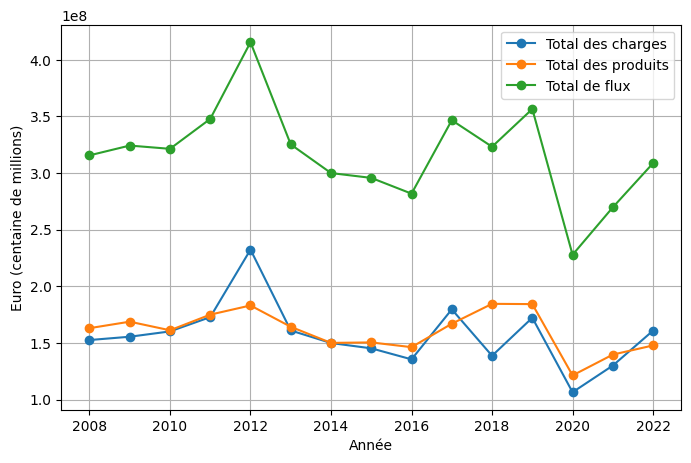

In [26]:
charge=df.groupby('année')['total des charges (ii + iv +vi + vii + viii + ix)'].sum()
produits=df.groupby('année')['total des produits (i + iii + v)'].sum()
tot=charge+produits
plt.figure(figsize=(8, 5))
plt.plot(charge.index, charge.values, marker="o", linestyle="-", label="Total des charges")
plt.plot(produits.index, produits.values, marker="o", linestyle="-", label="Total des produits")
plt.plot(tot.index,tot.values, marker="o", linestyle="-", label="Total de flux")
plt.xlabel("Année")
plt.ylabel("Euro (centaine de millions)")

plt.legend()
plt.grid()
plt.show()

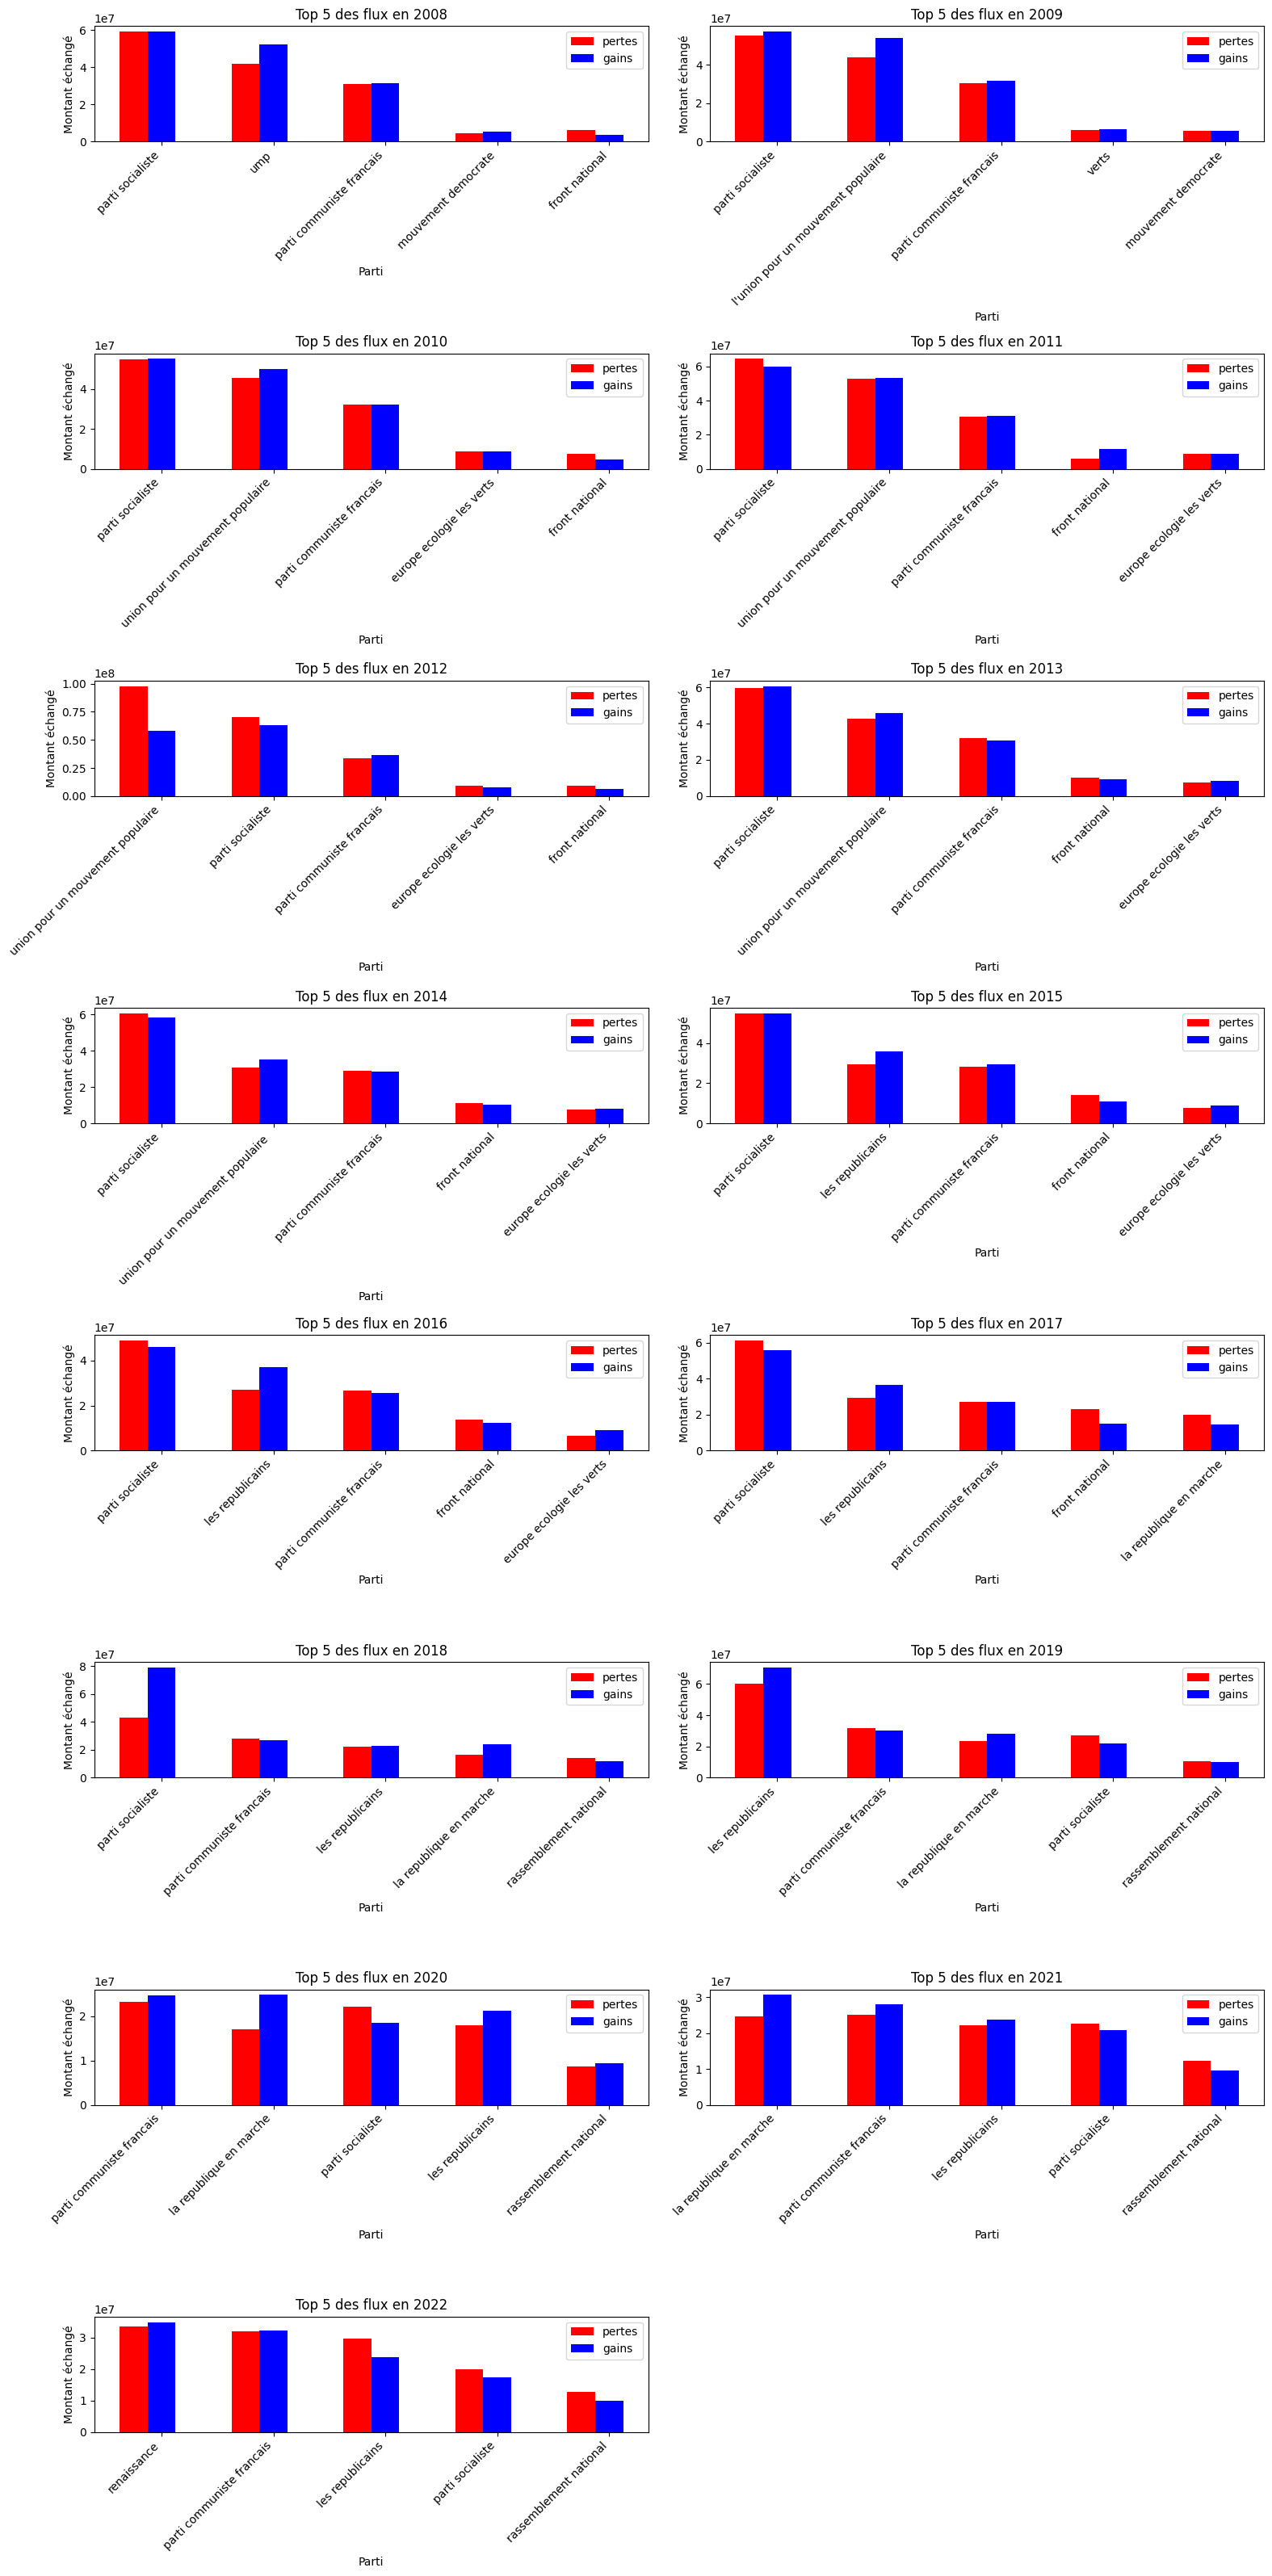

In [29]:
import matplotlib.pyplot as plt
import numpy as np

years = sorted(df["année"].unique())
N = 5
width = 0.25

n_years = len(years)
ncols = 2
nrows = int(np.ceil(n_years / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()  # pour accéder facilement avec un seul indice

for i, year in enumerate(years):
    ax = axes[i]
    df_y = df[df["année"] == year]
    top = df_y.nlargest(N, "total flux")

    ind = np.arange(N)
    bar1 = ax.bar(ind, top['total des charges (ii + iv +vi + vii + viii + ix)'], width, color="r")
    bar2 = ax.bar(ind + width, top['total des produits (i + iii + v)'], width, color="b")

    ax.set_xlabel("Parti")
    ax.set_ylabel("Montant échangé")
    ax.set_xticks(ind + width)
    ax.set_xticklabels(top['nom parti'], rotation=45, ha='right')
    ax.set_title(f"Top {N} des flux en {year}")
    ax.legend((bar1, bar2), ('pertes', 'gains'))

# Si tu as plus de cases que d'années, supprime les axes inutilisés
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [3]:
produits=['cotisations des adhérents', 'cotisations des élus',
       'aide publique 1ère fraction', 'aide publique 2nde fraction',
       'dons de personne physique',
       "dévolutions de l'excédent des comptes de campagne",
       'dévolutions de partis ou groupements politiques',
       'prestations de services (manifestations et colloques)',
       'ventes de marchandises, productions vendue (biens et services), production stockée et production immobilisée']


In [4]:
df[df['nom parti']=='la france insoumise']

,num parti,nom parti,année,immobilisations incorporelles,écarts d'acquisition,terrains et constructions,autres immobilisations corporelles,participations et créances rattachées,prêts à des partis ou groupements politiques,autres immobilisations financières,...,dévolutions de partis ou groupements politiques,prestations de services (manifestations et colloques),"ventes de marchandises, productions vendue (biens et services), production stockée et production immobilisée",total iii,total v,"reprise sur amortissements, dépréciations, provisions et transferts de charges",total des produits (i + iii + v),excédent ou déficit d'ensemble,total flux,deputes
107,976,la france insoumise,2017,0,0,0,2418,0,266301,5489,...,0,335066,306583,0,0,0,2189747,-695567,5075061,17
120,976,la france insoumise,2018,0,0,0,17307,305,0,5184,...,0,126928,30000,106797,0,0,5341706,2129850,8553562,17
132,976,la france insoumise,2019,0,0,0,27773,305,0,10116,...,0,83308,42487,12564,300,662353,5715327,2678978,8751675,17
144,976,la france insoumise,2020,0,0,0,32603,381,0,160756,...,0,109010,46116,13315,2001,23738,5553521,2127918,8979124,17
156,976,la france insoumise,2021,0,0,0,152194,381,0,170484,...,0,153705,279627,0,0,374677,6170949,463390,11878508,17
169,976,la france insoumise,2022,0,0,0,170928,381,0,190681,...,0,274560,369808,1,28,1748739,7599991,-4761055,19961038,75


In [ ]:
#df = df.loc[df['num parti'].isin(elected)]

In [5]:
df['année'].unique()

array([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018,
       2019, 2020, 2021, 2022], dtype=int64)

In [6]:
X=df.drop(columns=['nom parti','année','deputes','num parti'])

<Axes: >

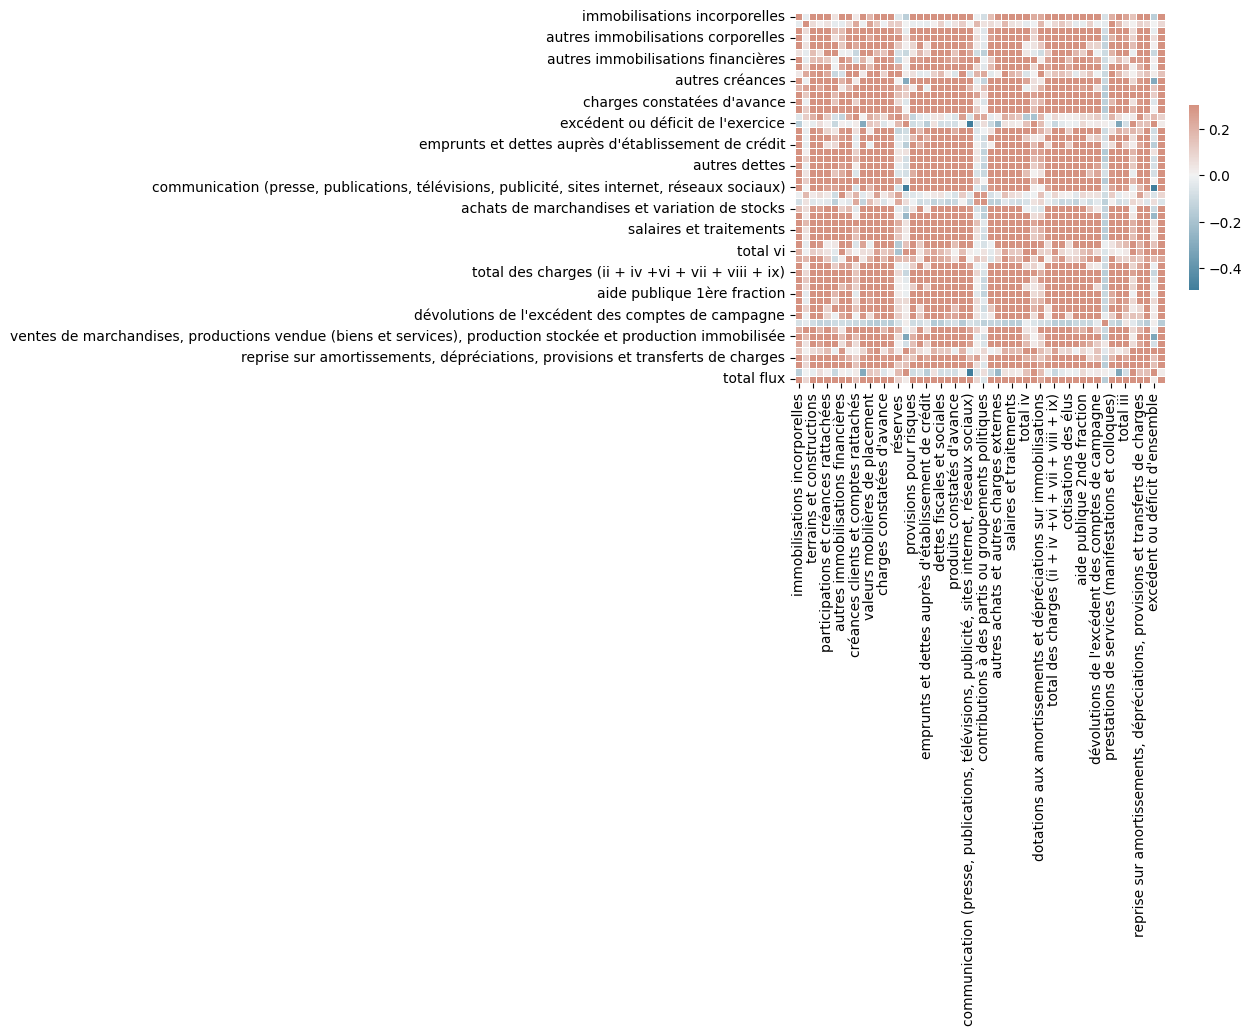

In [12]:
corr=X.corr()
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr,cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [7]:
X_scaled = StandardScaler().fit_transform(X)  

In [8]:
pca=PCA(n_components=52)
pca.fit(X_scaled)
print(np.cumsum(pca.explained_variance_ratio_))

[0.44669106 0.53875787 0.61242431 0.66888974 0.70986612 0.74273065
 0.77041482 0.79515357 0.81557858 0.83580118 0.85374821 0.87033278
 0.8848202  0.89861359 0.91020949 0.9196718  0.92890123 0.93698
 0.94473868 0.95175556 0.95750971 0.96308892 0.96775707 0.97229141
 0.9764665  0.98042144 0.98347882 0.98609503 0.98847527 0.99044356
 0.99216083 0.99372792 0.99471898 0.99556896 0.9963763  0.99700736
 0.99759874 0.99812703 0.99858716 0.99897407 0.99928236 0.99950253
 0.99969447 0.99982419 0.99990512 0.99996112 0.99998938 1.
 1.         1.         1.         1.        ]


In [9]:
pca=PCA(n_components=27)
main=pca.fit_transform(X_scaled)

In [10]:
main_df=pd.DataFrame(data=main,columns=[f'PC{i}' for i in range(1,28)])

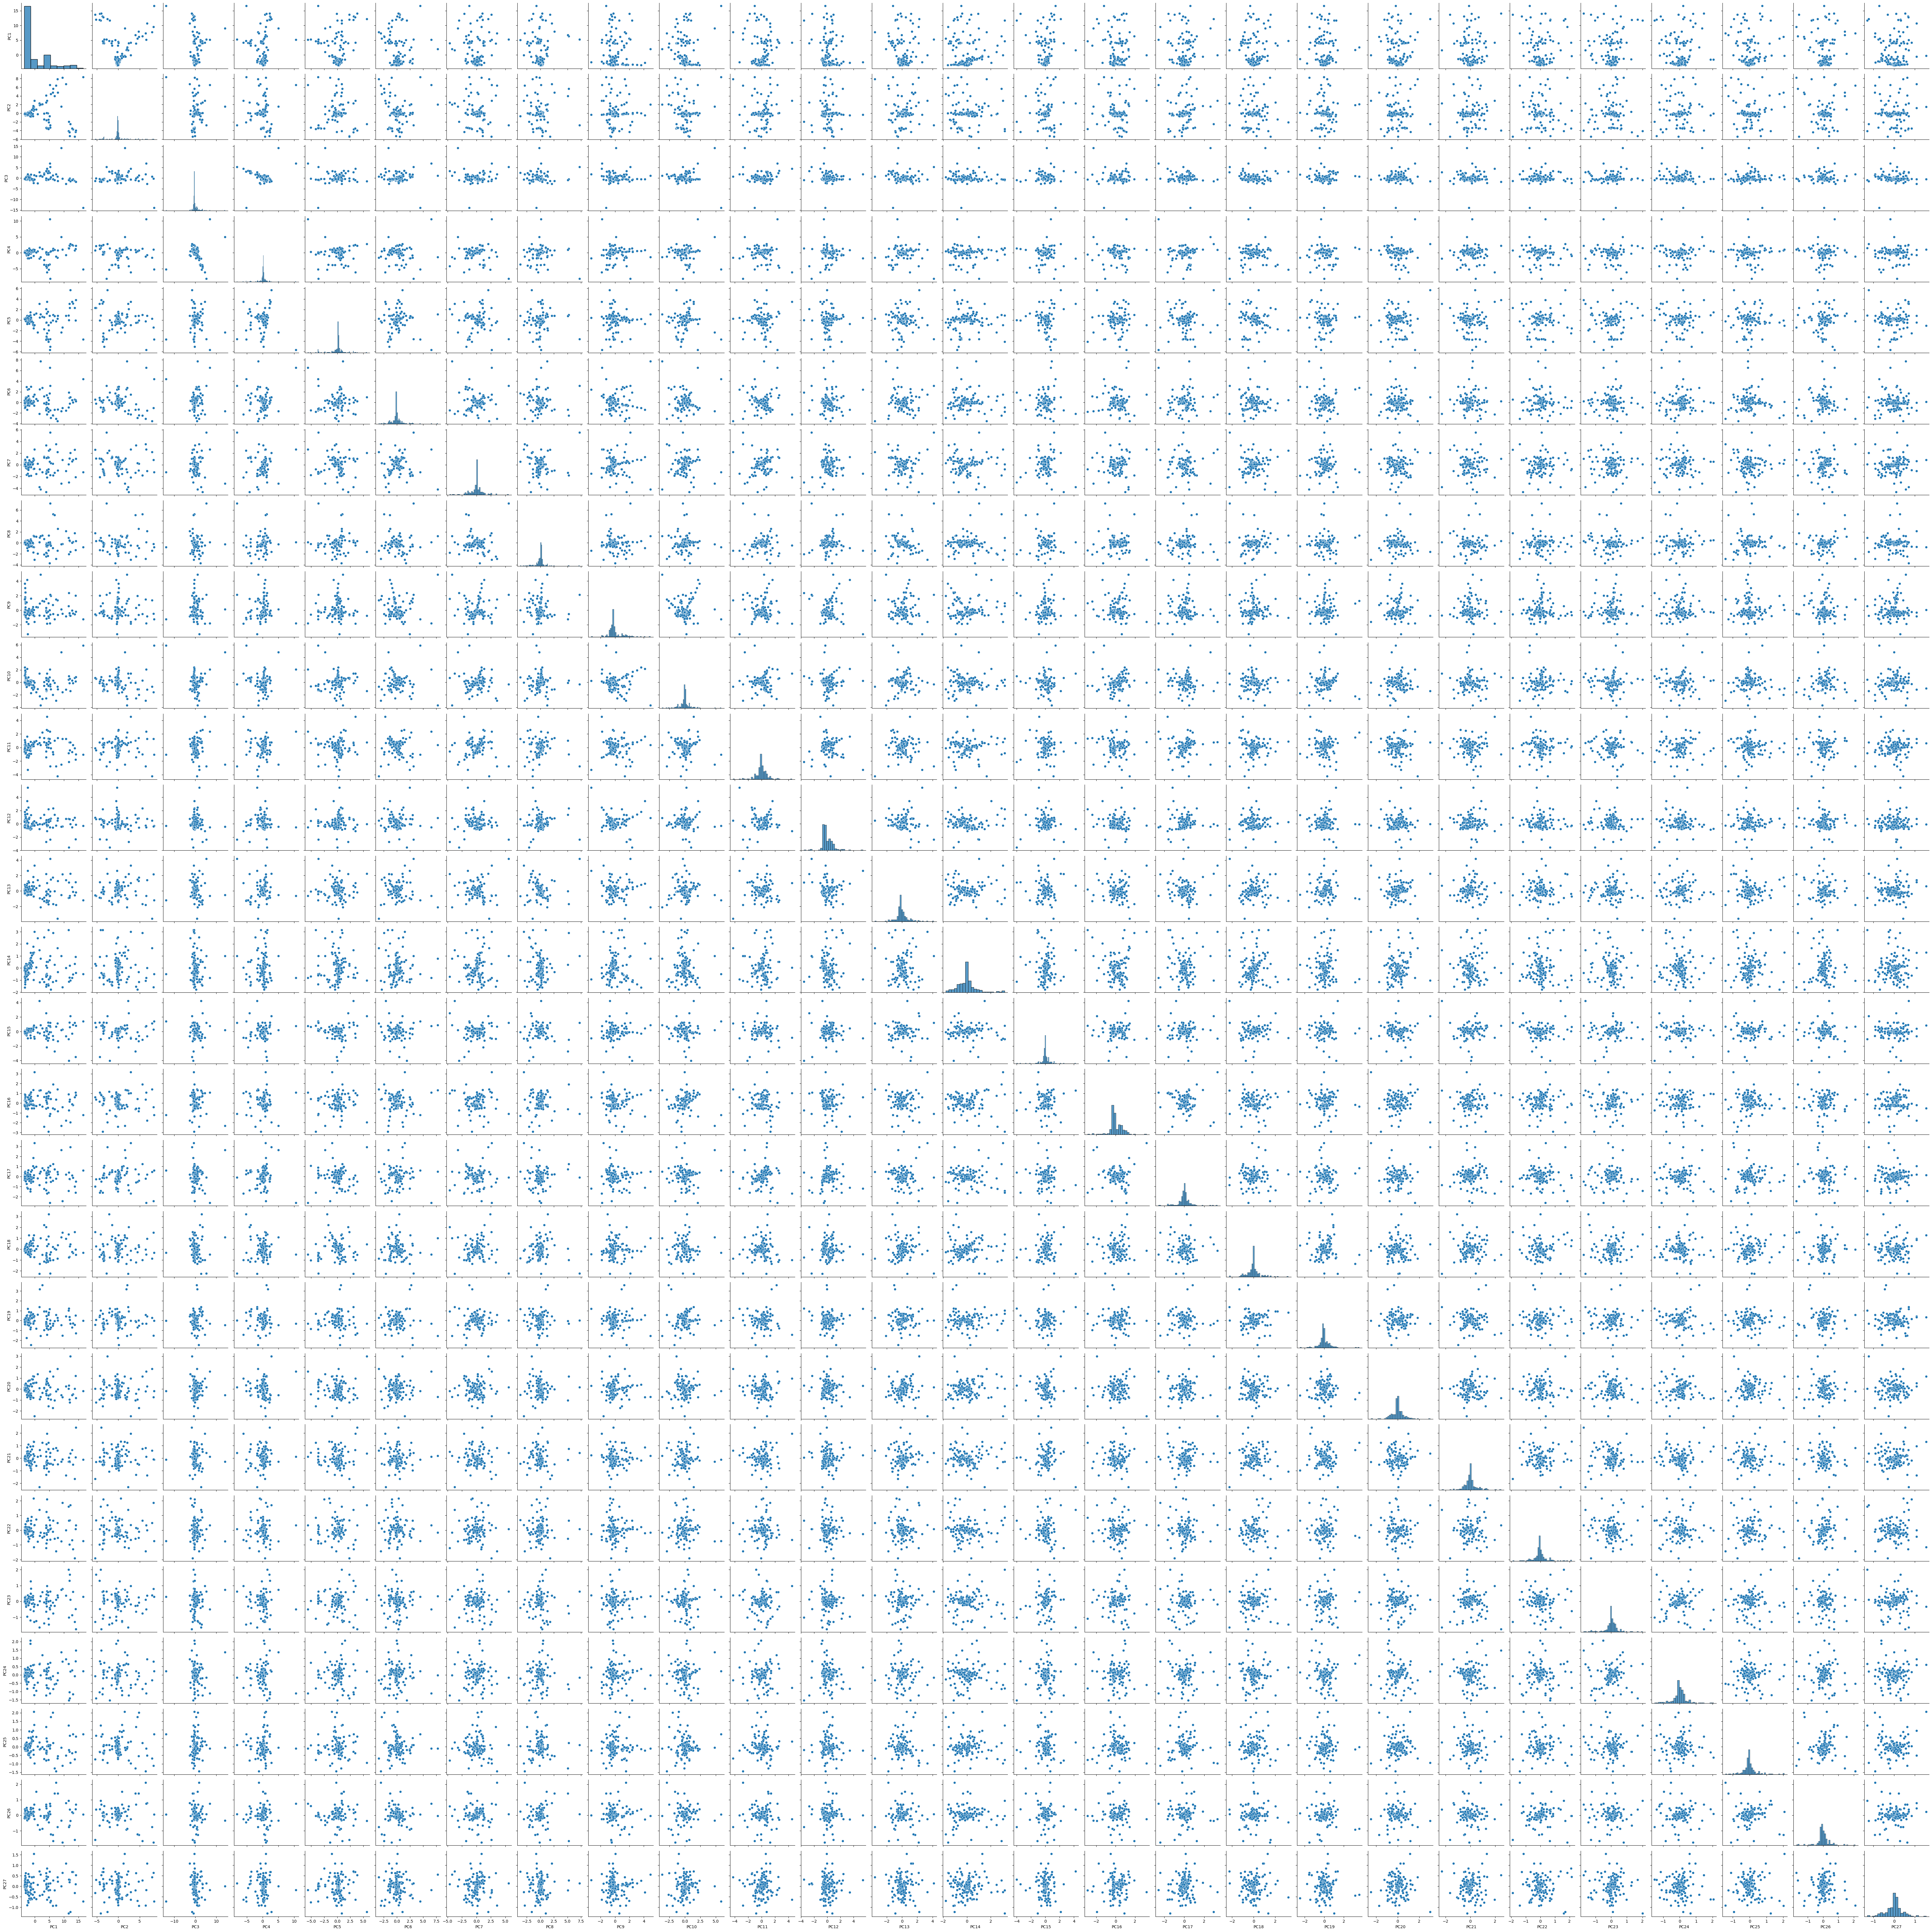

In [53]:
sns.pairplot(main_df)

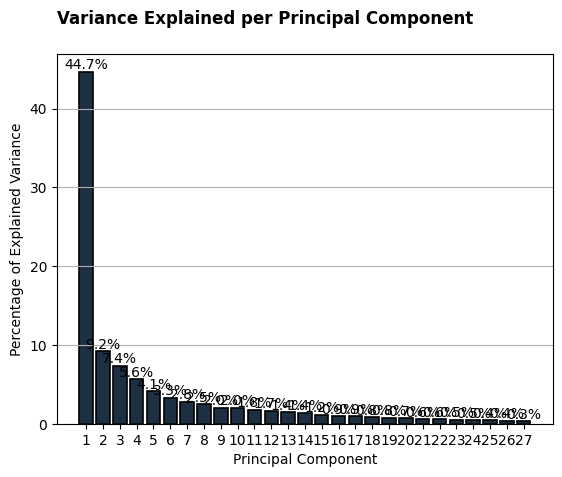

In [12]:
plot_y = [val * 100 for val in pca.explained_variance_ratio_]
plot_x = range(1, len(plot_y) + 1)

bars = plt.bar(plot_x, plot_y, align="center", color="#1C3041", edgecolor="#000000", linewidth=1.2)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.001, f"{yval:.1f}%", ha="center", va="bottom")

plt.xlabel("Principal Component")
plt.ylabel("Percentage of Explained Variance")
plt.title("Variance Explained per Principal Component", loc="left", fontdict={"weight": "bold"}, y=1.06)
plt.grid(axis="y")
plt.xticks(plot_x)

plt.show()

In [13]:
import plotly.express as px
import pandas as pd
total_explained_variance = sum(pca.explained_variance_ratio_[:3]) * 100
# Création du DataFrame avec les trois premières composantes principales
pca_3d_df = pd.DataFrame(main[:, :3], columns=["PC1", "PC2", "PC3"])
pca_3d_df["y"] = list(df["deputes"])

# Création de la colonne pour les tranches de députés
pca_3d_df["category"] = pca_3d_df["y"].apply(lambda x: f"entre {(x//50)*50} et {((x//50)+1)*50}")

# Création de la figure interactive avec Plotly
fig = px.scatter_3d(
    pca_3d_df, 
    x="PC1", y="PC2", z="PC3",
    color="category",  # Couleur basée sur les tranches de députés
    hover_data={"y": True},  # Affichage du nombre exact de députés au survol
    opacity=0.8
)

# Ajout du titre et des labels
fig.update_layout(
    title=f"Number of Deputes PCA ({total_explained_variance:.2f}% Explained Variance)",
    scene=dict(
        xaxis_title="Principal Component 1",
        yaxis_title="Principal Component 2",
        zaxis_title="Principal Component 3"
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

# Affichage de la figure interactive
fig.show()


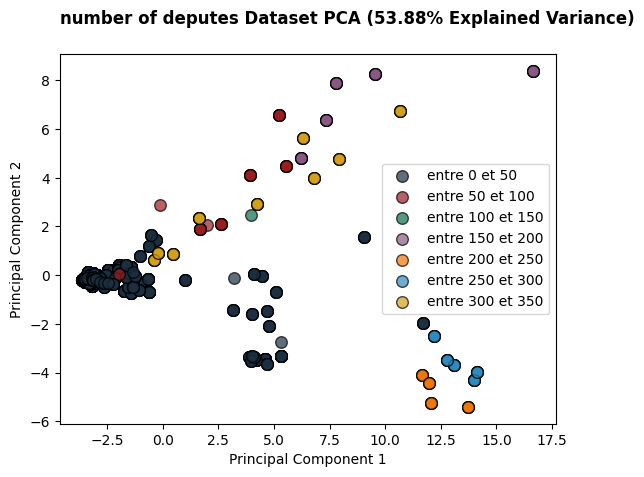

In [17]:
total_explained_variance = sum(pca.explained_variance_ratio_[:2]) * 100
colors = ["#1C3041", "#9B1D20", "#0B6E4F", "#895884", "#F07605", "#2E8BC0", "#D4A017"]


pca_2d_df = pd.DataFrame(main[:, :2], columns=["PC1", "PC2"])
pca_2d_df["y"] = list(df['deputes'])
used_labels = {}
fig, ax = plt.subplots()

k=0
for target in sorted(pca_2d_df["y"]):
    if target-k*50>50:
        k+=1
    subset = pca_2d_df[pca_2d_df["y"] == target]
    label = f"entre {k*50} et {(k+1)*50}" if k not in used_labels else None
    used_labels[k] = True
    ax.scatter(x=subset["PC1"], y=subset["PC2"], s=70, alpha=0.7, c=colors[k], edgecolors="#000000", label=label)


plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"number of deputes Dataset PCA ({total_explained_variance:.2f}% Explained Variance)", loc="left", fontdict={"weight": "bold"}, y=1.06)

ax.legend()
plt.show()

In [18]:
category_counts = pca_2d_df["y"].value_counts().sort_index()
ranked={0:0}
k=0
for i in category_counts.keys():
    if i>=(k+1)*50:
        k+=1
        ranked[k]=0
    ranked[k]+=category_counts[i]

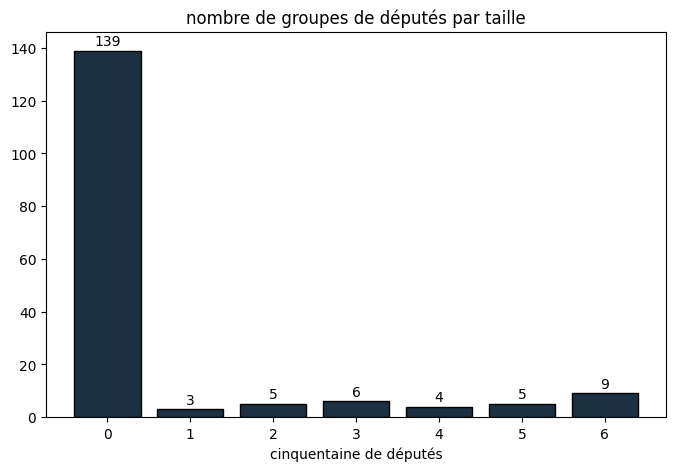

In [16]:


# Compter le nombre de députés dans chaque catégorie
category_counts = pca_2d_df["y"].value_counts().sort_index()

# Création du bar plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(list(ranked.keys()), list(ranked.values()), color="#1C3041", edgecolor="black")

# Labels et titre
ax.set_xlabel("cinquentaine de députés")
#ax.set_ylabel("Nombre de députés")
ax.set_title("nombre de groupes de députés par taille")

# Affichage des valeurs sur les barres
for i, v in enumerate(list(ranked.values())):
    ax.text(list(ranked.keys())[i], v + 2, str(v), ha='center', fontsize=10)

# Affichage du graphique
plt.show()


signification: entre 2008 et 2022 on a eu 5 groupe de députés comportant entre 100 et 150 membres, et 4 avec 200 à 250 membres

In [19]:
latest_names = df.sort_values("année").groupby("num parti")["nom parti"].last()

In [20]:
df['nom parti']=df['num parti'].map(latest_names)

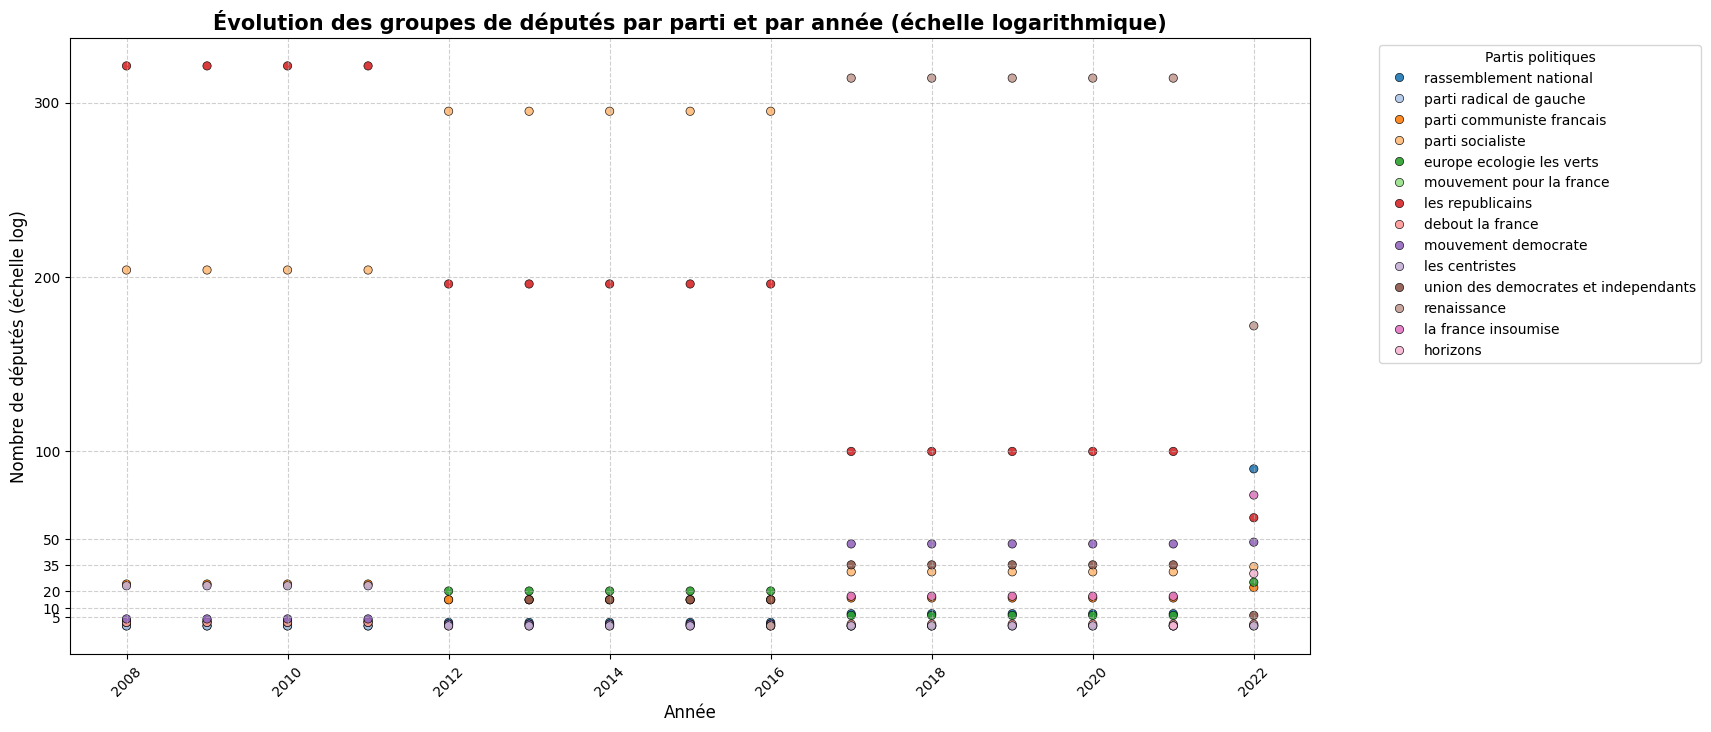

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(16, 8))  # Largeur augmentée pour une meilleure lisibilité

# Palette plus variée
custom_palette = sns.color_palette("tab20", n_colors=df["nom parti"].nunique())

scatter = sns.scatterplot(
    data=df, 
    x="année", 
    y="deputes", 
    hue="nom parti", 
    palette=custom_palette, 
    edgecolor="black", 
    alpha=0.9
)

# Appliquer une échelle logarithmique pour aérer les petits partis
#plt.yscale('log')

# Personnalisation des ticks pour qu'ils soient lisibles
yticks = [5, 10, 20,35, 50, 100, 200, 300]  # Exemple de valeurs adaptées
plt.yticks(yticks, [str(y) for y in yticks])

# Ajustements du graphique
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre de députés (échelle log)", fontsize=12)
plt.title("Évolution des groupes de députés par parti et par année (échelle logarithmique)", fontsize=15, fontweight="bold")

# Rotation des années pour une meilleure lisibilité
plt.xticks(rotation=45)

# Déplacement de la légende
plt.legend(title="Partis politiques", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajout d'une grille adaptée à l'échelle logarithmique
plt.grid(True, which="both", linestyle="--", alpha=0.6)

# Affichage du graphique
plt.show()


In [22]:
# selected_features=['total général (i + ii + iii)','total général (i + ii + iii + iv)','communication (presse, publications, télévisions, publicité, sites internet, réseaux sociaux)','total iv', 'total vi', 'total des charges (ii + iv +vi + vii + viii + ix)','total iii', 'total v','total des produits (i + iii + v)', "excédent ou déficit d'ensemble",
#        'total flux']

selected_features=['communication','total flux','total iv','immobilisations incorporelles','cotisations des élus','dettes fiscales et sociales']

ValueError: 'communication' is not in list

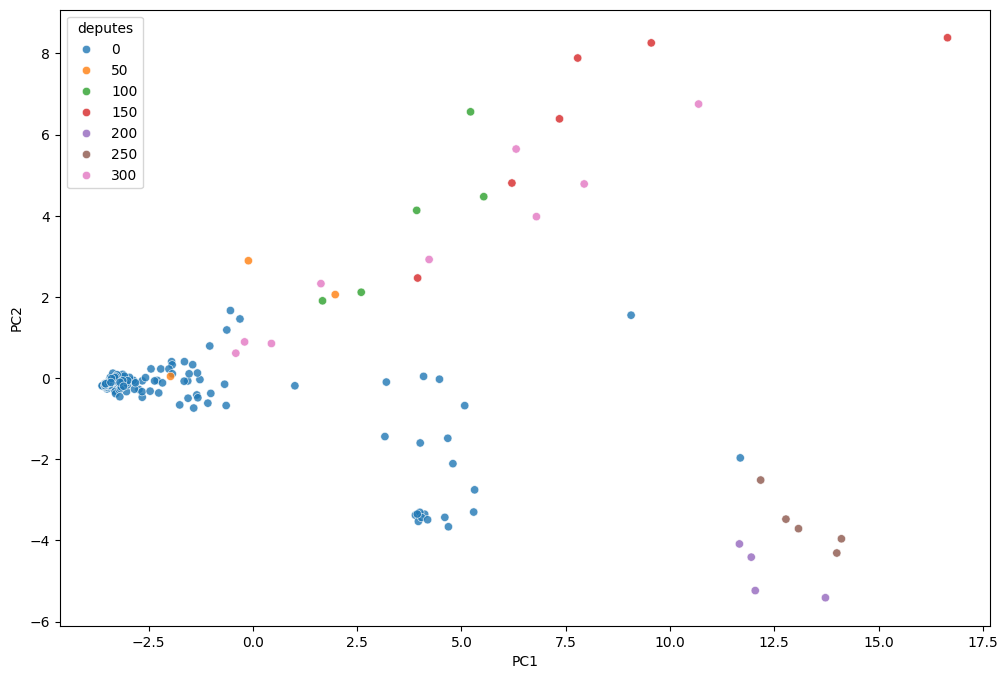

In [23]:
pca=PCA(n_components=2)
deput=[(i//50)*50 for i in list(df["deputes"])]
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"])
pca_df["deputes"] = deput#list(df["deputes"])
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="deputes", palette="tab10", alpha=0.8, ax=ax)
loadings = pca.components_.T  # Transposer pour avoir les variables en colonnes
feature_names = X.columns  # Récupérer les noms des variables originales

for i, feature in enumerate(selected_features):
    feature_idx = list(X.columns).index(feature)
    plt.arrow(0, 0, loadings[feature_idx, 0] * 5, loadings[feature_idx, 1] * 5, 
              color="red", alpha=0.5, head_width=0.2)
    plt.text(loadings[feature_idx, 0] * 5, loadings[feature_idx, 1] * 5, 
             feature, color="red", fontsize=12)

# Ajustements du graphique
ax.axhline(0, color='grey', linestyle="--", linewidth=0.8)
ax.axvline(0, color='grey', linestyle="--", linewidth=0.8)
ax.set_title(f"Biplot PCA ({sum(pca.explained_variance_ratio_[:2]) * 100:.2f}% de variance expliquée)", fontsize=14, fontweight="bold")
ax.set_xlabel("Composante Principale 1")
ax.set_ylabel("Composante Principale 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

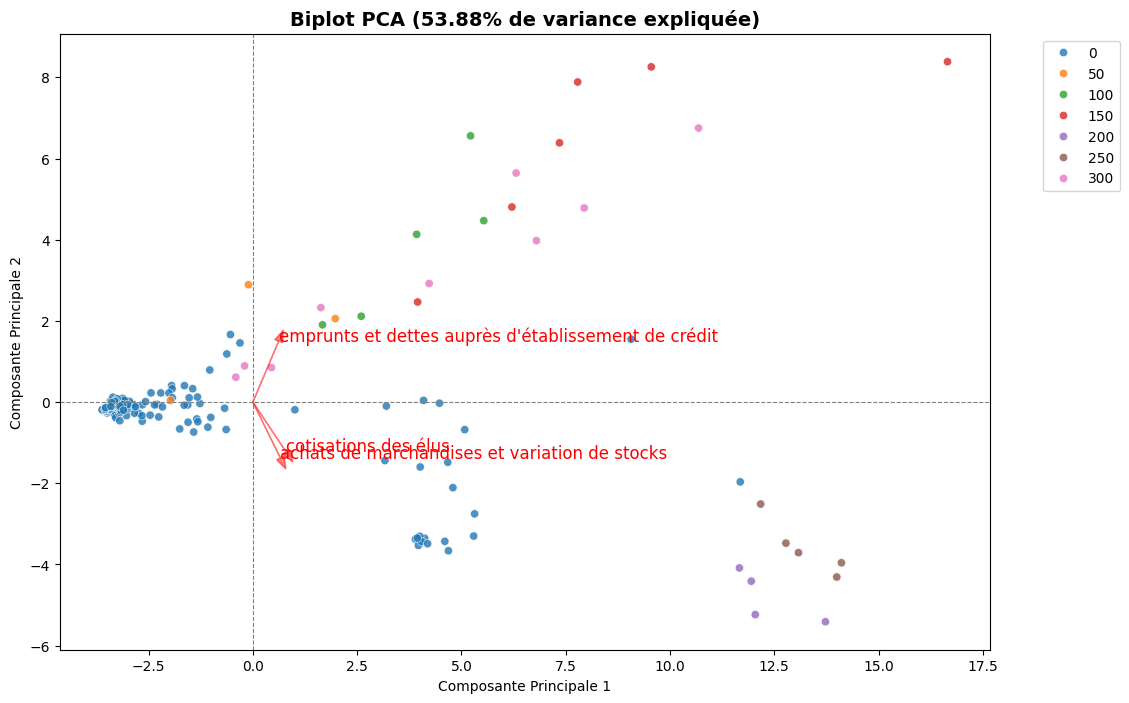

In [38]:
pca = PCA(n_components=2)
deput = [(i // 50) * 50 for i in list(df["deputes"])]
principal_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(principal_components, columns=["PC1", "PC2"])
pca_df["deputes"] = deput

# Création du scatterplot
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="deputes", palette="tab10", alpha=0.8, ax=ax)

# Calcul des "loadings"
loadings = pca.components_.T  # shape: (n_features, 2)
feature_names = X.columns


importance = np.linalg.norm(loadings, axis=1)
imp=np.argsort(importance)
top5_indices = [imp[-3],imp[-1],imp[-4]][::-1] 
top5_features = [(feature_names[i], loadings[i, 0], loadings[i, 1]) for i in top5_indices]

# Affichage des flèches des top features
for feature, x_loading, y_loading in top5_features:
    plt.arrow(0, 0, x_loading * 5, y_loading * 5, color="red", alpha=0.5, head_width=0.2)
    plt.text(x_loading * 5, y_loading * 5, feature, color="red", fontsize=12)

# Réglages du biplot
ax.axhline(0, color='grey', linestyle="--", linewidth=0.8)
ax.axvline(0, color='grey', linestyle="--", linewidth=0.8)
ax.set_title(f"Biplot PCA ({sum(pca.explained_variance_ratio_[:2]) * 100:.2f}% de variance expliquée)", fontsize=14, fontweight="bold")
ax.set_xlabel("Composante Principale 1")
ax.set_ylabel("Composante Principale 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [46]:
top5_features

[("emprunts et dettes auprès d'établissement de crédit",
  0.12362802287744712,
  0.30009047151185964),
 ('total iv', 0.09528860959891047, 0.2946457190221475),
 ('achats de marchandises et variation de stocks',
  0.13207644021479464,
  -0.2754607764373342),
 ('cotisations des élus', 0.15859254751797772, -0.24462500177656904),
 ('valeurs mobilières de placement', 0.13445021430783352, -0.2517259645618527),
 ('participations et créances rattachées',
  0.15027726134955444,
  -0.2346379366556554)]

In [44]:
df

,num parti,nom parti,année,immobilisations incorporelles,écarts d'acquisition,terrains et constructions,autres immobilisations corporelles,participations et créances rattachées,prêts à des partis ou groupements politiques,autres immobilisations financières,...,dévolutions de partis ou groupements politiques,prestations de services (manifestations et colloques),"ventes de marchandises, productions vendue (biens et services), production stockée et production immobilisée",total iii,total v,"reprise sur amortissements, dépréciations, provisions et transferts de charges",total des produits (i + iii + v),excédent ou déficit d'ensemble,total flux,deputes
0,40,front national,2008,24537,0,4198171,741272,14000,717658,93728,...,15000,196224,206599,45986,86966,163809,3854207,-2445426,10153840,0
1,52,parti radical de gauche,2008,0,0,76225,74503,0,0,73793,...,418225,22871,95534,18376,234,0,2047197,35293,4059101,0
2,60,parti communiste francais,2008,0,0,6070376,695940,103251,11494547,51696,...,0,777259,1960503,272132,250770,389767,31559485,725272,62393698,24
3,76,parti socialiste,2008,245377,0,14048629,2574300,1348989,1767573,492160,...,89885,739962,3359598,470816,712047,2192099,59166852,17139,118316565,204
4,104,les verts,2008,23465,0,0,2221669,103665,0,401382,...,6000,128265,286247,23892,158579,81592,5166761,439834,9893688,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,531,les centristes,2022,431,0,0,0,0,0,8850,...,0,0,0,0,460,11230,440658,14775,866540,0
167,709,union des democrates et independants,2022,988,0,0,87188,3504,0,115832,...,0,85428,148451,30604,171,41833,3419648,466945,6372350,6
168,910,renaissance,2022,4590,0,31279266,8847935,0,0,40847,...,3462,44648,201407,16186,0,4796126,34866826,1327646,68406005,172
169,976,la france insoumise,2022,0,0,0,170928,381,0,190681,...,0,274560,369808,1,28,1748739,7599991,-4761055,19961038,75
